In [1]:
import os
import re

import numpy as np
import torch
import pandas as pd
from val_test import val_test
from print_results import print_results
import pickle
from tqdm.notebook import tqdm
from functionsgpu_old import *
from plotting_betas import *
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from functools import reduce
from video_saving import *
from plotting_beta import *

import warnings
warnings.filterwarnings("ignore")

device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
print(device)

if device.type == "cuda":
    idx = device.index if device.index is not None else torch.cuda.current_device()
    print(torch.cuda.get_device_name(idx))

dtype = torch.float32


def deterministic():
    SEED = 42
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    # Enable deterministic operations (may slow down training slightly)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

deterministic()
tslen = 200

functionsgpu_old.py device: cuda:1
cuda:1
NVIDIA RTX A5000


In [2]:
def z_create(X, encode_fn, mu_all_t_tensor):
    z = encode_fn(X)
    std_dev = torch.std(z, dim=0)
    order = torch.argsort(std_dev, descending=True)
    z = z[:, order]
    std_dev = std_dev[order]
    z_mean = encode_fn(mu_all_t_tensor.view(1, -1))
    z_mean = z_mean[:, order]
    return z, z_mean, std_dev

## Data Loading

In [3]:
def loading(filename, tslen):
    with open('{}/betas_aligned{}.pkl'.format(filename, tslen), 'rb') as f:
        betas_aligned = pickle.load(f)
    with open('{}/mu{}.pkl'.format(filename, tslen), 'rb') as f:
        mu = pickle.load(f)
    with open('{}/tangent_vecs{}.pkl'.format(filename, tslen), 'rb') as f:
        tangent_vec_all = pickle.load(f)
    return betas_aligned, mu, tangent_vec_all

betas_aligned_all, mu_all_t, tangent_vec_all = loading('aligned_data',tslen)
mu_all_t_tensor = torch.from_numpy(mu_all_t).to(device=device, dtype=torch.float32)
betas_aligned = np.array(betas_aligned_all)
betas_aligned = betas_aligned.transpose(1, 2, 3, 0)

y = torch.tensor([0]*44 + [1]*111, dtype=dtype, device=device)
print(betas_aligned.shape, tangent_vec_all.shape, mu_all_t.shape)

(32, 3, 200, 155) (32, 3, 200, 155) (32, 3, 200)


In [4]:
K = 32
M = 3
T = tslen
nsamples = 155

tangent_flat = tangent_vec_all.reshape((K*M*T, nsamples)).T
print(tangent_flat.shape)

(155, 19200)


## Creating Dataloader

In [5]:
batch_size = 32
# tangent_flat (nsamples, K*M*T) = (155, 19200); y length 155 (one per subject)
# each batch: x_tangent (64, 19200), y_labels (64,) when batch_size=64
X_tangent = torch.from_numpy(tangent_flat.astype(np.float32))
# Keep labels on CPU so the whole dataset is CPU-side; move to device when loading batch
y_tangent = y.flatten()[:X_tangent.size(0)].clone().cpu()
tangent_dataset = TensorDataset(X_tangent, y_tangent)
# Generator must match default device (cuda:1 set by functionsgpu_old); CPU generator raises RuntimeError
loader_generator = torch.Generator(device=device)
tangent_loader = DataLoader(tangent_dataset, batch_size=batch_size, shuffle=True, drop_last=False, generator=loader_generator)

# Nonlinear Tangent VAE

In [6]:
class NonlinearVAE(nn.Module):
    def __init__(self, D, R, H=128):
        super().__init__()
        self.H = H
        # Encoder layers
        self.encoder = nn.Sequential(
            nn.Linear(D, H, bias=False),
            nn.Tanh(),
            nn.LayerNorm(H))
        
        self.fc_mu = nn.Linear(H, R, bias=False)
        self.fc_logvar = nn.Linear(H, R, bias=False)               

        self.decoder = nn.Sequential(
            nn.Linear(R, H, bias=False),
            nn.Tanh(),
            nn.Linear(H, D, bias=False))

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        x_hat = self.decoder(z)
        return x_hat

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar, z


def vae_loss(x, x_hat, mu, logvar, beta=1e-4):
    recon = ((x_hat - x)**2).sum(dim=1)
    kl = 0.5 * (logvar.exp() + mu.pow(2) - 1 - logvar).sum(dim=1)
    return (recon + beta * kl).mean(), recon.mean(), kl.mean()

In [7]:
# One Forward Pass
input_dim = K*M*T
latent_dim = 2
model = NonlinearVAE(input_dim, latent_dim).to(device=device, dtype=dtype)
print(model)

batch = next(iter(tangent_loader))
X, y = batch
X = X.to(device=device, dtype=dtype)
print(X.shape, y.shape)

X_hat, mu, logvar, z = model(X)
print(X_hat.shape, mu.shape, logvar.shape, z.shape)

loss, recon, kl = vae_loss(X, X_hat, mu, logvar)
print(loss.item(), recon.item(), kl.item())


NonlinearVAE(
  (encoder): Sequential(
    (0): Linear(in_features=19200, out_features=128, bias=False)
    (1): Tanh()
    (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (fc_mu): Linear(in_features=128, out_features=2, bias=False)
  (fc_logvar): Linear(in_features=128, out_features=2, bias=False)
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=False)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=19200, bias=False)
  )
)
torch.Size([32, 19200]) torch.Size([32])
torch.Size([32, 19200]) torch.Size([32, 2]) torch.Size([32, 2]) torch.Size([32, 2])
1619.542724609375 1619.542724609375 0.48867732286453247


In [8]:
model.eval()

def vae_encode(x):
    mu,_ = model.encode(x)
    return mu

def vae_decode(z):
    return model.decode(z)

def vae_reparameterize(x):
    mu, logvar = model.encode(x)
    return model.reparameterize(mu, logvar)

z, z_mean, std_dev = z_create(X, vae_encode, mu_all_t_tensor)
print(z.shape, z_mean.shape, std_dev.shape)

torch.Size([32, 2]) torch.Size([1, 2]) torch.Size([2])


## Training on Full Dataset

  0%|          | 0/1000 [00:00<?, ?it/s]

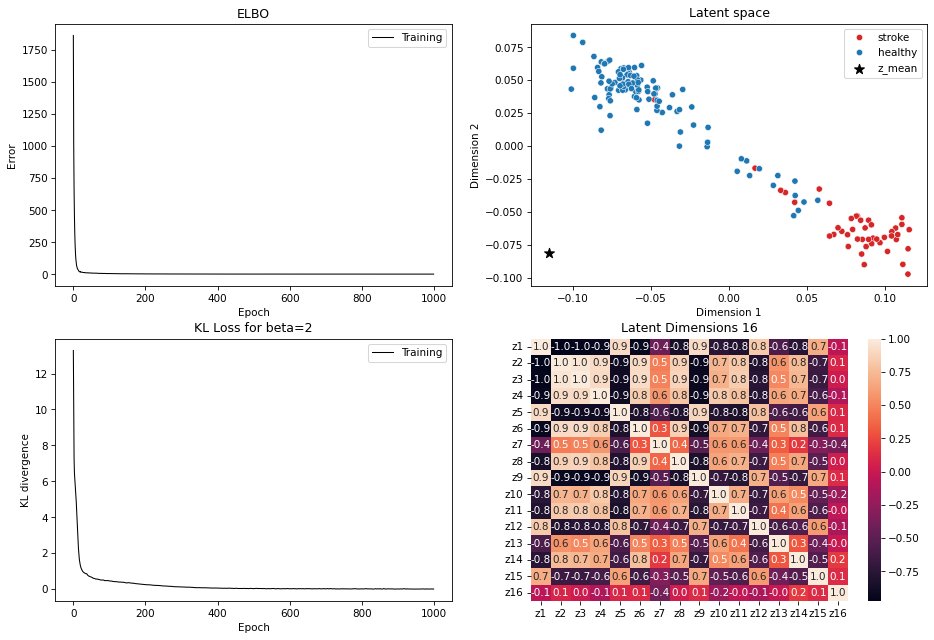

In [9]:
%matplotlib inline
from IPython.display import Image, display, clear_output
import seaborn as sns
from tqdm.notebook import tqdm
deterministic()

input_dim = K*M*T
latent_dim = 16
beta = 2

tmp_img = "tangent_vae_out.png"
model = NonlinearVAE(input_dim, latent_dim).to(device=device, dtype=dtype)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

train_loss = []
train_kl = []

for epoch in tqdm(range(1000)):
    batch_loss, batch_kl = [], []
    model.train()

    # Go through each batch in the training dataset using the loader
    # Note that y is not necessarily known as it is here
    for batch in tangent_loader:
        x_train, y_train = batch
        x_train = x_train.to(device=device, dtype=dtype)
        x_train_hat, mu, logvar, z_train = model(x_train)
        elbo, recon, kl = vae_loss(x_train, x_train_hat, mu, logvar, beta=beta)

        opt.zero_grad()
        elbo.backward()
        opt.step()

        batch_loss.append(elbo.item())
        batch_kl.append(kl.item())

    train_loss.append(np.mean(batch_loss))
    train_kl.append(np.mean(batch_kl))

# -- Plotting (after all epochs) --
f, axarr = plt.subplots(2, 2, figsize=(15, 10))
# ELBO Loss
ax = axarr[0, 0]
ax.set_title("ELBO")
ax.set_xlabel('Epoch')
ax.set_ylabel('Error')
ax.plot(np.arange(len(train_loss)), train_loss, color="black")
ax.legend(['Training'])

# KL Loss
ax = axarr[1, 0]
ax.set_title(f"KL Loss for beta={beta}")
ax.set_xlabel('Epoch')
ax.set_ylabel('KL divergence')
ax.plot(np.arange(len(train_kl)), train_kl, color="black")
ax.legend(['Training'])

# Latent space scatter plot
ax = axarr[0, 1]
x_plot = X_tangent.to(device=device, dtype=dtype)
z, z_mean, std_dev = z_create(x_plot, vae_encode, mu_all_t_tensor)
z = z.detach().cpu().numpy()

y_rep = y_tangent.cpu().numpy()
zdf = pd.DataFrame(z, columns=["z{}".format(i+1) for i in range(z.shape[1])])
label_map = {0: "stroke", 1: "healthy"}
zdf['label'] = np.vectorize(label_map.get)(y_rep)

sns.scatterplot(data=zdf, x="z1", y="z2", hue="label", ax=ax, palette={"stroke": "tab:red", "healthy": "tab:blue"})
# add z_mean
z_mean_np = z_mean.detach().cpu().numpy()
ax.scatter(z_mean_np[0, 0], z_mean_np[0, 1],color="black",marker="*",label="z_mean",s=100)
ax.legend()
ax.set_title("Latent space")
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')

ax = axarr[1, 1]
zdf.drop(columns=['label'], inplace=True)
sns.heatmap(zdf.corr(), annot=True, fmt=".1f", ax=ax)
ax.set_title(f'Latent Dimensions {latent_dim}')

plt.show()

In [10]:
%matplotlib qt5
X_tangent_device = X_tangent.to(device=device, dtype=dtype)
X_hat, mu, logvar, z = model(X_tangent_device)
plot_one_traj(exp_gpu(mu_all_t_tensor , X_hat[1,:].reshape(32,3,tslen)))

libGL error: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: swrast


In [11]:
def skeleton_mode(tangent_vec_all, mu_all_t_tensor, latent_dim, decoder, R=2):
    K, M, T = tangent_vec_all.shape[:3]
    scales = [-2, 0, 2]
    betas_hat = []
    
    for r in range(R):
        modes = []
        z_mode = torch.zeros(1, latent_dim, device=device, dtype=dtype)
        for s in scales:
            z_mode[:, r] = s
            with torch.no_grad():
                v = decoder(z_mode)
            v = v.reshape(K, M, T)
            beta_hat = exp_gpu(mu_all_t_tensor, v)
            modes.append(beta_hat.detach().cpu().numpy())

        p_all = plotting_betas_landmark(
            modes,
            colors=[(1, 0, 0), (0, 0, 0), (0, 0.5, 1)]
        )
        betas_hat.extend(modes)
    return betas_hat

In [12]:
# %matplotlib qt5
# betas_hat = skeleton_mode(tangent_vec_all, mu_all_t_tensor, latent_dim, vae_decode, R=3)

In [13]:
# %matplotlib inline
# landmark_idx = 12
# coord_idx = 2  # z
# scales = [-2, 0, 2]
# R = 3

# axes = plt.subplots(1, R, figsize=(4 * R, 3.5), sharey=True)[1]
# if R == 1:
#     axes = [axes]
# for r in range(R):
#     ax = axes[r]
#     for scale_idx, s in enumerate(scales):
#         beta = betas_hat[r * len(scales) + scale_idx]  # (K, M, T)
#         traj = beta[landmark_idx, coord_idx, :]        # (T,)
#         ax.plot(traj, label=f'scale={s}')
#     ax.set_title(f'Mode r={r+1}')
#     ax.set_xlabel('Time')
#     if r == 0:
#         ax.set_ylabel(f'Landmark {landmark_idx}, coord z')
#     ax.legend()
# plt.tight_layout()
# plt.show()

In [14]:
def skeleton_mode2(tangent_vec_all,mu_all_t_tensor,latent_dim,decoder,z_mean,std_dev,R=2):
    K, M, T = tangent_vec_all.shape[:3]
    scales = [-2, 0, 2]
    betas_hat = []

    for r in range(R):
        modes = []

        for s in scales:
            z_mode = z_mean.clone()
            z_mode[:, r] += s * std_dev[r]

            with torch.no_grad():
                v = decoder(z_mode)

            v = v.reshape(K, M, T)
            beta_hat = exp_gpu(mu_all_t_tensor, v)
            modes.append(beta_hat.detach().cpu().numpy())

        plotting_betas_landmark(
            modes,
            colors=[(1, 0, 0), (0, 0, 0), (0, 0.5, 1)]
        )

        betas_hat.extend(modes)

    return betas_hat

In [15]:
# %matplotlib qt5
# betas_hat = skeleton_mode2(tangent_vec_all, mu_all_t_tensor, latent_dim, vae_decode, z_mean, std_dev,R=3)

In [16]:
# %matplotlib inline
# landmark_idx = 12
# coord_idx = 2  # z
# scales = [-2, 0, 2]
# R = 3

# axes = plt.subplots(1, R, figsize=(4 * R, 3.5), sharey=True)[1]
# if R == 1:
#     axes = [axes]
# for r in range(R):
#     ax = axes[r]
#     for scale_idx, s in enumerate(scales):
#         beta = betas_hat[r * len(scales) + scale_idx]  # (K, M, T)
#         traj = beta[landmark_idx, coord_idx, :]        # (T,)
#         ax.plot(traj, label=f'scale={s}')
#     ax.set_title(f'Mode r={r+1}')
#     ax.set_xlabel('Time')
#     if r == 0:
#         ax.set_ylabel(f'Landmark {landmark_idx}, coord z')
#     ax.legend()
# plt.tight_layout()
# plt.show()